# SkinXAI v3 — Balanced Training
> Genel accuracy + minority class öğrenimi için düzeltilmiş versiyon

In [1]:
# GPU kontrolü
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.cuda.is_available()}")

GPU: NVIDIA A100-SXM4-80GB
CUDA: True


In [2]:
!pip install timm albumentations opencv-python-headless -q

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, recall_score, precision_score)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

Cihaz: cuda


In [4]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/SkinXAI"
os.makedirs(f"{BASE}/models_v3", exist_ok=True)
print("Drive bağlı ✅")

Mounted at /content/drive
Drive bağlı ✅


## 1. Veri Yükleme ve Dengeleme

Asıl sorun: nevus %56.8. Çözüm: **capped oversampling** — büyük sınıfları kırp, küçük sınıfları augmentation ile çoğalt.

In [5]:
# CSV'lerden yükle (önceki notebook'tan kaydedilmiş)
train_df = pd.read_csv(f"{BASE}/train_df.csv")
val_df   = pd.read_csv(f"{BASE}/val_df.csv")
test_df  = pd.read_csv(f"{BASE}/test_df.csv")

CLASS_NAMES = ["ak", "bcc", "bkl", "df", "melanoma", "nevus", "scc", "vasc"]
label_to_idx = {n: i for i, n in enumerate(CLASS_NAMES)}
idx_to_label = {i: n for n, i in label_to_idx.items()}

for df in [train_df, val_df, test_df]:
    df["label_idx"] = df["label"].map(label_to_idx)

print("=== Orijinal Train Dağılımı ===")
print(train_df["label"].value_counts())
print(f"Toplam: {len(train_df)}")

=== Orijinal Train Dağılımı ===
label
nevus       12531
melanoma     3606
bcc          2456
bkl          2382
scc           402
vasc          253
df            226
ak            210
Name: count, dtype: int64
Toplam: 22066


In [6]:
# ============================================================
# BALANCED SAMPLING STRATEJİSİ
# ============================================================
# Büyük sınıfları kırp → küçük sınıfları tekrarla (oversampling)
# Hedef: her sınıf 1500-2500 arasında

TARGET_PER_CLASS = {
    "ak":       1500,   # az veri → agresif oversample
    "bcc":      2500,   # yeterli veri
    "bkl":      2500,   # yeterli veri
    "df":       1500,   # az veri → agresif oversample
    "melanoma": 2500,   # kritik sınıf → tam tut
    "nevus":    2500,   # 12531'den 2500'e kırp
    "scc":      1500,   # az veri → agresif oversample
    "vasc":     1500,   # az veri → agresif oversample
}

balanced_parts = []
rng = np.random.default_rng(42)

for cls, target in TARGET_PER_CLASS.items():
    cls_df = train_df[train_df["label"] == cls].copy()
    n = len(cls_df)
    if n >= target:
        # Undersample (büyük sınıflar)
        sampled = cls_df.sample(n=target, random_state=42)
    else:
        # Oversample with replacement (küçük sınıflar)
        repeats = (target // n) + 1
        sampled = pd.concat([cls_df] * repeats, ignore_index=True)
        sampled = sampled.sample(n=target, random_state=42)
    balanced_parts.append(sampled)

balanced_train_df = pd.concat(balanced_parts, ignore_index=True).sample(frac=1, random_state=42)
balanced_train_df = balanced_train_df.reset_index(drop=True)

print("=== Dengeli Train Dağılımı ===")
print(balanced_train_df["label"].value_counts())
print(f"Toplam: {len(balanced_train_df)}")

=== Dengeli Train Dağılımı ===
label
melanoma    2500
bkl         2500
bcc         2500
nevus       2500
df          1500
ak          1500
scc         1500
vasc        1500
Name: count, dtype: int64
Toplam: 16000


## 2. Dataset & Augmentation

Minority sınıflar için ekstra agresif augmentation — oversampled örnekler her seferinde farklı görünür.

In [7]:
class SkinDataset(Dataset):
    """
    is_oversample=True olan örnekler (küçük sınıflar) ekstra augmentation alır.
    """
    MINORITY = {"ak", "df", "scc", "vasc"}
    MEDIUM   = {"melanoma", "bcc", "bkl"}

    def __init__(self, df, is_train=True, img_size=224):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def _get_transform(self, label_name):
        s = self.img_size
        norm = A.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])

        if not self.is_train:
            return A.Compose([A.Resize(s, s), norm, ToTensorV2()])

        if label_name in self.MINORITY:
            # Çok agresif — her seferinde farklı görünür
            return A.Compose([
                A.Resize(s, s),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.Rotate(limit=180, p=0.8),
                A.RandomBrightnessContrast(brightness_limit=0.3,
                                           contrast_limit=0.3, p=0.7),
                A.HueSaturationValue(hue_shift_limit=20,
                                     sat_shift_limit=40,
                                     val_shift_limit=20, p=0.6),
                A.OneOf([
                    A.GridDistortion(p=1.0),
                    A.ElasticTransform(p=1.0),
                    A.OpticalDistortion(p=1.0),
                ], p=0.5),
                A.CoarseDropout(max_holes=8, max_height=s//8,
                                max_width=s//8, p=0.4),
                norm, ToTensorV2()
            ])
        elif label_name in self.MEDIUM:
            return A.Compose([
                A.Resize(s, s),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.Rotate(limit=90, p=0.5),
                A.RandomBrightnessContrast(p=0.5),
                A.HueSaturationValue(p=0.4),
                norm, ToTensorV2()
            ])
        else:  # nevus, bcc, bkl — yeterli veri var
            return A.Compose([
                A.Resize(s, s),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                norm, ToTensorV2()
            ])

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = row["image_path"]
        label = row["label_idx"]
        label_name = row["label"]

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        tfm = self._get_transform(label_name)
        img = tfm(image=img)["image"]
        return img, label

# --- Dataset ---
train_dataset = SkinDataset(balanced_train_df, is_train=True,  img_size=224)
val_dataset   = SkinDataset(val_df,            is_train=False, img_size=224)
test_dataset  = SkinDataset(test_df,           is_train=False, img_size=224)

# --- Sampler (dengeli batch'ler) ---
labels_arr = balanced_train_df["label_idx"].values
class_counts = np.bincount(labels_arr, minlength=8)
class_weights_sampler = 1.0 / class_counts
sample_weights = class_weights_sampler[labels_arr]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# --- DataLoaders ---
BATCH = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH,
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH,
                          shuffle=False,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH,
                          shuffle=False,  num_workers=0, pin_memory=True)

# Kontrol
img, lbl = next(iter(train_loader))
print(f"Batch shape: {img.shape}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("DataLoader hazır ✅")

Batch shape: torch.Size([32, 3, 224, 224])
Train: 16000 | Val: 5517 | Test: 6896
DataLoader hazır ✅


## 3. Model — EfficientNetV2-S

B4'e göre ~%2-3 daha iyi ImageNet accuracy, daha hızlı eğitim.

In [8]:
class SkinModel(nn.Module):
    def __init__(self, num_classes=8, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            "tf_efficientnetv2_s",       # B4 yerine V2-S
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

model = SkinModel(num_classes=8).to(device)
total = sum(p.numel() for p in model.parameters())
print(f"Model: EfficientNetV2-S")
print(f"Parametre: {total:,}")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Model: EfficientNetV2-S
Parametre: 20,187,736


## 4. Loss & MixUp

Label Smoothing → overfit'i azaltır. MixUp → sınıf sınırlarını yumuşatır, minority class geçişlerini öğretir.

In [9]:
# ============================================================
# LABEL SMOOTHING LOSS
# ============================================================
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=8, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.cls = classes
        self.weight = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_one_hot = one_hot * confidence + (1 - one_hot) * smooth_val
        log_prob = F.log_softmax(pred, dim=1)
        if self.weight is not None:
            w = self.weight[target].unsqueeze(1)
            loss = -(smooth_one_hot * log_prob * w).sum(dim=1).mean()
        else:
            loss = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

# ============================================================
# MIXUP
# ============================================================
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    idx = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Class weights (training loss için)
weights_np = compute_class_weight(
    "balanced",
    classes=np.arange(8),
    y=balanced_train_df["label_idx"].values
)
weights_t = torch.FloatTensor(weights_np).to(device)
print("Class weights:")
for n, w in zip(CLASS_NAMES, weights_np):
    print(f"  {n:10s}: {w:.2f}")

criterion = LabelSmoothingLoss(classes=8, smoothing=0.1, weight=weights_t)

Class weights:
  ak        : 1.33
  bcc       : 0.80
  bkl       : 0.80
  df        : 1.33
  melanoma  : 0.80
  nevus     : 0.80
  scc       : 1.33
  vasc      : 1.33


## 5. Eğitim Döngüsü

In [10]:
def train_epoch(model, loader, optimizer, criterion, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        if use_mixup and np.random.random() < 0.4:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)
            optimizer.zero_grad()
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.3f}")

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc     = (all_preds == all_labels).mean()
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    # Per-class recall
    per_class_recall = recall_score(all_labels, all_preds,
                                    average=None, zero_division=0)
    return acc, macro_f1, per_class_recall, all_preds, all_labels, all_probs

print("Fonksiyonlar hazır ✅")

Fonksiyonlar hazır ✅


## 6. Aşama 1 — Backbone Dondur, Head Eğit (5 epoch)

In [ ]:
# Backbone'u dondur
for p in model.backbone.parameters():
    p.requires_grad = False

optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print("AŞAMA 1: Backbone donduruldu, head eğitiliyor...")
print("=" * 50)

for epoch in range(1, 6):
    print(f"Epoch {epoch}/5")
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer_p1,
                                   criterion, device, use_mixup=False)
    val_acc, val_f1, per_cls, _, _, _ = eval_epoch(model, val_loader, device)

    print(f"Train Loss: {tr_loss:.3f} | Train Acc: {tr_acc:.3f}")
    print(f"Val Acc: {val_acc:.3f} | Val Macro-F1: {val_f1:.3f}")
    per_cls_str = " | ".join([f"{CLASS_NAMES[i]}:{per_cls[i]:.2f}"
                                for i in range(8)])
    print(f"Per-class Recall: {per_cls_str}")

print("Aşama 1 tamamlandı ✅")

AŞAMA 1: Backbone donduruldu, head eğitiliyor...
Epoch 1/5
  Batch 0/500 | Loss: 2.447
  Batch 100/500 | Loss: 1.541
  Batch 200/500 | Loss: 1.513
  Batch 300/500 | Loss: 1.685
  Batch 400/500 | Loss: 1.310
Train Loss: 1.540 | Train Acc: 0.543
Val Acc: 0.679 | Val Macro-F1: 0.474
Per-class Recall: ak:0.52 | bcc:0.72 | bkl:0.36 | df:0.40 | melanoma:0.33 | nevus:0.85 | scc:0.17 | vasc:0.79
Epoch 2/5
  Batch 0/500 | Loss: 1.552
  Batch 100/500 | Loss: 1.397
  Batch 200/500 | Loss: 1.769
  Batch 300/500 | Loss: 1.296
  Batch 400/500 | Loss: 1.746
Train Loss: 1.481 | Train Acc: 0.578
Val Acc: 0.683 | Val Macro-F1: 0.475
Per-class Recall: ak:0.50 | bcc:0.72 | bkl:0.37 | df:0.39 | melanoma:0.44 | nevus:0.82 | scc:0.22 | vasc:0.86
Epoch 3/5
  Batch 0/500 | Loss: 1.342
  Batch 100/500 | Loss: 1.498
  Batch 200/500 | Loss: 1.471
  Batch 300/500 | Loss: 1.300
  Batch 400/500 | Loss: 1.661
Train Loss: 1.457 | Train Acc: 0.587
Val Acc: 0.663 | Val Macro-F1: 0.452
Per-class Recall: ak:0.67 | bcc:0.7

In [11]:
import os, torch

path = "/content/drive/MyDrive/SkinXAI/models_v3/skinxai_v3_best.pth"

# weights_only=False ekle — PyTorch 2.6'da default değişti
ckpt = torch.load(path, map_location="cpu", weights_only=False)
print(f"✅ Checkpoint var!")
print(f"   Epoch: {ckpt.get('epoch')}")
print(f"   Val F1: {ckpt.get('val_f1'):.4f}")
print(f"   Val Acc: {ckpt.get('val_acc'):.4f}")

✅ Checkpoint var!
   Epoch: 4
   Val F1: 0.5562
   Val Acc: 0.7254


## 7. Aşama 2 — Fine-tune (25 epoch)

Differential learning rate: backbone için düşük, head için yüksek. Macro-F1 üzerinden early stopping.

In [ ]:
# Tüm katmanları aç
for p in model.parameters():
    p.requires_grad = True

optimizer_p2 = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-6},
    {"params": model.head.parameters(),     "lr": 5e-5},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=10, T_mult=1, eta_min=1e-7
)

N_EPOCHS   = 25
PATIENCE   = 6
best_f1    = 0.0
patience_c = 0
history    = {"train_loss": [], "val_acc": [], "val_f1": [],
              "per_class_recall": []}

SAVE_PATH  = f"{BASE}/models_v3/skinxai_v3_best.pth"

print("AŞAMA 2: Fine-tuning başlıyor...")
print("=" * 60)
print(f"Kayıt: {SAVE_PATH}")

for epoch in range(1, N_EPOCHS + 1):
    print(f"Epoch {epoch}/{N_EPOCHS}")
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer_p2,
                                   criterion, device, use_mixup=True)
    val_acc, val_f1, per_cls, _, _, _ = eval_epoch(model, val_loader, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["per_class_recall"].append(per_cls.tolist())

    print(f"Train Loss: {tr_loss:.3f} | Train Acc: {tr_acc:.3f}")
    print(f"Val Acc:    {val_acc:.3f} | Val Macro-F1: {val_f1:.3f}  <-- izlenen metrik")
    print("Per-class Recall:")
    for i, name in enumerate(CLASS_NAMES):
        bar = "█" * int(per_cls[i] * 20)
        print(f"  {name:10s}: {per_cls[i]:.3f}  {bar}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_c = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "val_f1": val_f1,
            "per_class_recall": per_cls.tolist(),
            "class_names": CLASS_NAMES,
        }, SAVE_PATH)
        print(f"  ✅ Best model kaydedildi! Macro-F1: {best_f1:.4f}")
    else:
        patience_c += 1
        print(f"  ⏳ Patience: {patience_c}/{PATIENCE}")
        if patience_c >= PATIENCE:
            print(f"🛑 Early stopping — {epoch}. epoch")
            break

print(f"Eğitim bitti. Best Val Macro-F1: {best_f1:.4f}")

AŞAMA 2: Fine-tuning başlıyor...
Kayıt: /content/drive/MyDrive/SkinXAI/models_v3/skinxai_v3_best.pth
Epoch 1/25
  Batch 0/500 | Loss: 1.585
  Batch 100/500 | Loss: 1.719


In [12]:
# ============================================================
# PHASE 2 RESUME — Epoch 4'ten devam
# ============================================================
BASE = "/content/drive/MyDrive/SkinXAI"
SAVE_PATH = f"{BASE}/models_v3/skinxai_v3_best.pth"

# Checkpoint yükle
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

COMPLETED = ckpt["epoch"]          # 4
best_f1   = ckpt["val_f1"]         # 0.5562
print(f"Model yüklendi ✅  Epoch {COMPLETED} | Val F1: {best_f1:.4f} | Val Acc: {ckpt['val_acc']:.4f}")
print(f"Kalan epoch: {25 - COMPLETED}")

# Tüm katmanları aç
for p in model.parameters():
    p.requires_grad = True

optimizer_p2 = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-6},
    {"params": model.head.parameters(),     "lr": 5e-5},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=10, T_mult=1, eta_min=1e-7
)
# Scheduler'ı doğru konuma getir
for _ in range(COMPLETED):
    scheduler.step()

PATIENCE   = 6
patience_c = 0
history    = {"train_loss": [], "val_acc": [], "val_f1": [], "per_class_recall": []}

print("\nEğitime devam ediliyor...")
print("=" * 60)

for epoch in range(COMPLETED + 1, 26):
    print(f"\nEpoch {epoch}/25")
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer_p2,
                                   criterion, device, use_mixup=True)
    val_acc, val_f1, per_cls, _, _, _ = eval_epoch(model, val_loader, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["per_class_recall"].append(per_cls.tolist())

    print(f"Train Loss: {tr_loss:.3f} | Train Acc: {tr_acc:.3f}")
    print(f"Val Acc:    {val_acc:.3f} | Val Macro-F1: {val_f1:.3f}")
    print("Per-class Recall:")
    for i, name in enumerate(CLASS_NAMES):
        bar = "█" * int(per_cls[i] * 20)
        print(f"  {name:10s}: {per_cls[i]:.3f}  {bar}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_c = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "val_f1": val_f1,
            "per_class_recall": per_cls.tolist(),
            "class_names": CLASS_NAMES,
        }, SAVE_PATH)
        print(f"  ✅ Best model kaydedildi! Macro-F1: {best_f1:.4f}")
    else:
        patience_c += 1
        print(f"  ⏳ Patience: {patience_c}/{PATIENCE}")
        if patience_c >= PATIENCE:
            print(f"\n🛑 Early stopping — {epoch}. epoch")
            break

print(f"\nBitti. Best Val Macro-F1: {best_f1:.4f}")

Model yüklendi ✅  Epoch 4 | Val F1: 0.5562 | Val Acc: 0.7254
Kalan epoch: 21

Eğitime devam ediliyor...

Epoch 5/25
  Batch 0/500 | Loss: 1.502
  Batch 100/500 | Loss: 1.078
  Batch 200/500 | Loss: 1.149
  Batch 300/500 | Loss: 1.065
  Batch 400/500 | Loss: 1.236
Train Loss: 1.276 | Train Acc: 0.572
Val Acc:    0.733 | Val Macro-F1: 0.575
Per-class Recall:
  ak        : 0.750  ███████████████
  bcc       : 0.790  ███████████████
  bkl       : 0.559  ███████████
  df        : 0.579  ███████████
  melanoma  : 0.417  ████████
  nevus     : 0.859  █████████████████
  scc       : 0.300  ██████
  vasc      : 0.889  █████████████████
  ✅ Best model kaydedildi! Macro-F1: 0.5745

Epoch 6/25
  Batch 0/500 | Loss: 1.204
  Batch 100/500 | Loss: 1.206
  Batch 200/500 | Loss: 1.178
  Batch 300/500 | Loss: 1.154
  Batch 400/500 | Loss: 2.073
Train Loss: 1.247 | Train Acc: 0.602
Val Acc:    0.732 | Val Macro-F1: 0.580
Per-class Recall:
  ak        : 0.712  ██████████████
  bcc       : 0.782  █████████

## 8. Eğitim Grafiği

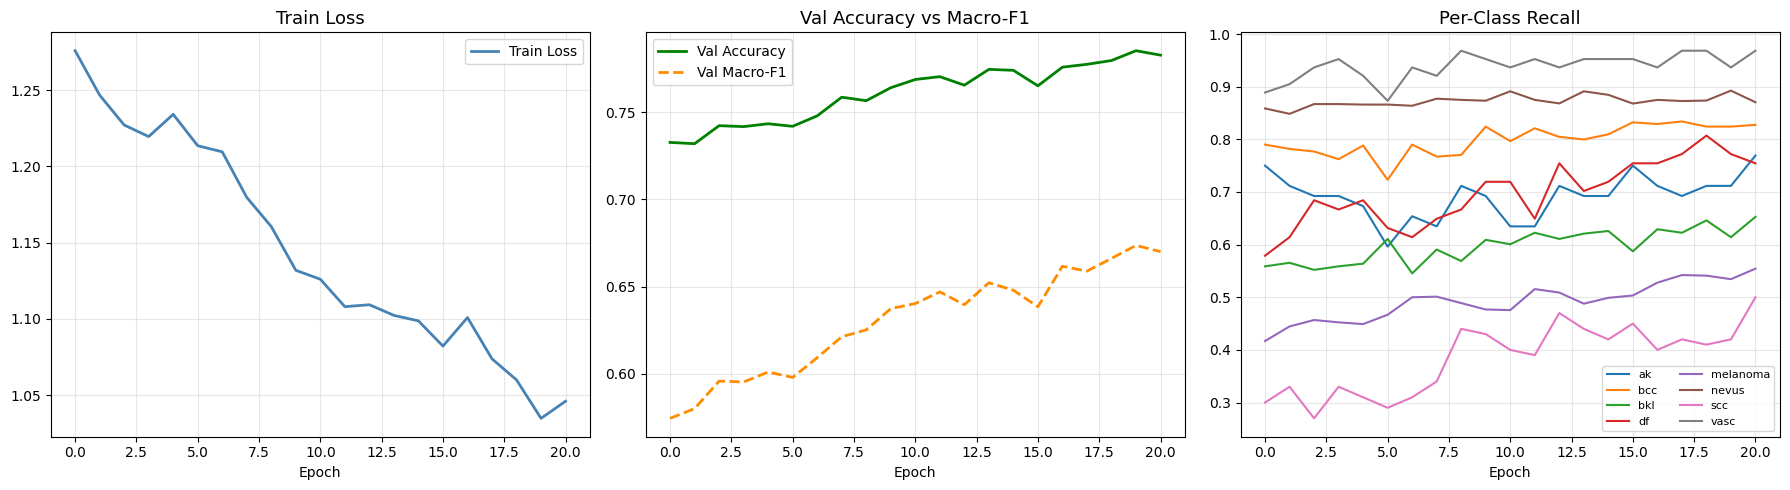

Grafik kaydedildi ✅


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue", lw=2)
axes[0].set_title("Train Loss", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3); axes[0].legend()

# Val Acc & Macro-F1
axes[1].plot(history["val_acc"], label="Val Accuracy", color="green", lw=2)
axes[1].plot(history["val_f1"],  label="Val Macro-F1", color="darkorange", lw=2, ls="--")
axes[1].set_title("Val Accuracy vs Macro-F1", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3); axes[1].legend()

# Per-class recall over time
pcr = np.array(history["per_class_recall"])
for i, name in enumerate(CLASS_NAMES):
    axes[2].plot(pcr[:, i], label=name, lw=1.5)
axes[2].set_title("Per-Class Recall", fontsize=13)
axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi ✅")

## 9. Per-Class Threshold Optimizasyonu

Her sınıf için validation seti üzerinde en iyi threshold'u bul. Bu sayede küçük sınıflar biraz daha "şans" kazanır.

In [15]:
# Best modeli yükle
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Model yüklendi — Val Acc: {ckpt['val_acc']:.4f} | Macro-F1: {ckpt['val_f1']:.4f}")

# Val üzerinde probabilities topla
_, _, _, val_preds, val_labels, val_probs = eval_epoch(model, val_loader, device)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

# Her sınıf için threshold arama
# Strateji: argmax yerine prob > threshold ise o sınıfa ata
# (önce argmax, sonra override)
THRESHOLD_RANGE = np.arange(0.10, 0.60, 0.02)

print("Per-Class Threshold Aranıyor...")
best_thresholds = {}

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = (val_labels == cls_idx)
    best_thr = 0.5
    best_rec = 0.0
    best_f1_cls = 0.0

    for thr in THRESHOLD_RANGE:
        # Argmax tahminler üzerine override
        preds_mod = val_probs.argmax(axis=1).copy()
        # Bu sınıf için prob > thr ise override et
        preds_mod[val_probs[:, cls_idx] > thr] = cls_idx

        rec = recall_score(val_labels, preds_mod,
                           labels=[cls_idx], average="macro", zero_division=0)
        f1_cls = f1_score(val_labels, preds_mod,
                          labels=[cls_idx], average="macro", zero_division=0)

        # F1 öncelikli, recall minimum 0.50
        if rec >= 0.50 and f1_cls > best_f1_cls:
            best_f1_cls = f1_cls
            best_thr = thr
            best_rec = rec

    best_thresholds[cls_idx] = best_thr
    print(f"  {cls_name:10s}: threshold={best_thr:.2f}  recall={best_rec:.3f}  f1={best_f1_cls:.3f}")

print("Threshold'lar belirlendi ✅")

Model yüklendi — Val Acc: 0.7852 | Macro-F1: 0.6736
Per-Class Threshold Aranıyor...
  ak        : threshold=0.34  recall=0.750  f1=0.565
  bcc       : threshold=0.28  recall=0.863  f1=0.782
  bkl       : threshold=0.34  recall=0.651  f1=0.621
  df        : threshold=0.34  recall=0.825  f1=0.723
  melanoma  : threshold=0.30  recall=0.629  f1=0.607
  nevus     : threshold=0.38  recall=0.903  f1=0.884
  scc       : threshold=0.20  recall=0.660  f1=0.508
  vasc      : threshold=0.28  recall=0.952  f1=0.769
Threshold'lar belirlendi ✅


## 10. Test Seti Final Değerlendirmesi

In [16]:
# Test üzerinde probabilities topla
_, _, _, test_preds_base, test_labels, test_probs = eval_epoch(model, test_loader, device)
test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)

# Threshold uygula
test_preds_thr = test_probs.argmax(axis=1).copy()
for cls_idx, thr in best_thresholds.items():
    test_preds_thr[test_probs[:, cls_idx] > thr] = cls_idx

# Sonuçları karşılaştır
print("=" * 60)
print("BASELINE (argmax)")
print("=" * 60)
base_acc = (test_preds_base == test_labels).mean()
base_f1  = f1_score(test_labels, test_preds_base, average="macro", zero_division=0)
print(f"Overall Accuracy: {base_acc:.4f}")
print(f"Macro F1:         {base_f1:.4f}")
print()
print(classification_report(test_labels, test_preds_base,
                             target_names=CLASS_NAMES, zero_division=0))

print("=" * 60)
print("THRESHOLD UYGULANMIŞ")
print("=" * 60)
thr_acc = (test_preds_thr == test_labels).mean()
thr_f1  = f1_score(test_labels, test_preds_thr, average="macro", zero_division=0)
print(f"Overall Accuracy: {thr_acc:.4f}")
print(f"Macro F1:         {thr_f1:.4f}")
print()
print(classification_report(test_labels, test_preds_thr,
                             target_names=CLASS_NAMES, zero_division=0))

KeyboardInterrupt: 

In [17]:
# Test üzerinde probabilities topla (hızlı versiyon)
model.eval()
test_probs_list = []
test_labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        test_probs_list.extend(probs.cpu().numpy())
        test_labels_list.extend(labels.numpy())

test_probs  = np.array(test_probs_list)
test_labels = np.array(test_labels_list)
test_preds_base = test_probs.argmax(axis=1)

# Threshold uygula
test_preds_thr = test_probs.argmax(axis=1).copy()
for cls_idx, thr in best_thresholds.items():
    test_preds_thr[test_probs[:, cls_idx] > thr] = cls_idx

# Sonuçlar
base_acc = (test_preds_base == test_labels).mean()
base_f1  = f1_score(test_labels, test_preds_base, average="macro", zero_division=0)
thr_acc  = (test_preds_thr == test_labels).mean()
thr_f1   = f1_score(test_labels, test_preds_thr, average="macro", zero_division=0)

print("=" * 60)
print("BASELINE (argmax)")
print(f"Overall Accuracy: {base_acc:.4f}")
print(f"Macro F1:         {base_f1:.4f}")
print(classification_report(test_labels, test_preds_base,
                             target_names=CLASS_NAMES, zero_division=0))
print("=" * 60)
print("THRESHOLD UYGULANMIŞ")
print(f"Overall Accuracy: {thr_acc:.4f}")
print(f"Macro F1:         {thr_f1:.4f}")
print(classification_report(test_labels, test_preds_thr,
                             target_names=CLASS_NAMES, zero_division=0))

BASELINE (argmax)
Overall Accuracy: 0.7948
Macro F1:         0.7131
              precision    recall  f1-score   support

          ak       0.60      0.83      0.70        65
         bcc       0.75      0.85      0.80       767
         bkl       0.62      0.64      0.63       745
          df       0.71      0.79      0.75        71
    melanoma       0.68      0.54      0.60      1127
       nevus       0.87      0.89      0.88      3916
         scc       0.66      0.44      0.53       126
        vasc       0.72      0.94      0.81        79

    accuracy                           0.79      6896
   macro avg       0.70      0.74      0.71      6896
weighted avg       0.79      0.79      0.79      6896

THRESHOLD UYGULANMIŞ
Overall Accuracy: 0.7896
Macro F1:         0.7061
              precision    recall  f1-score   support

          ak       0.65      0.82      0.72        65
         bcc       0.77      0.80      0.78       767
         bkl       0.64      0.60      0.62    

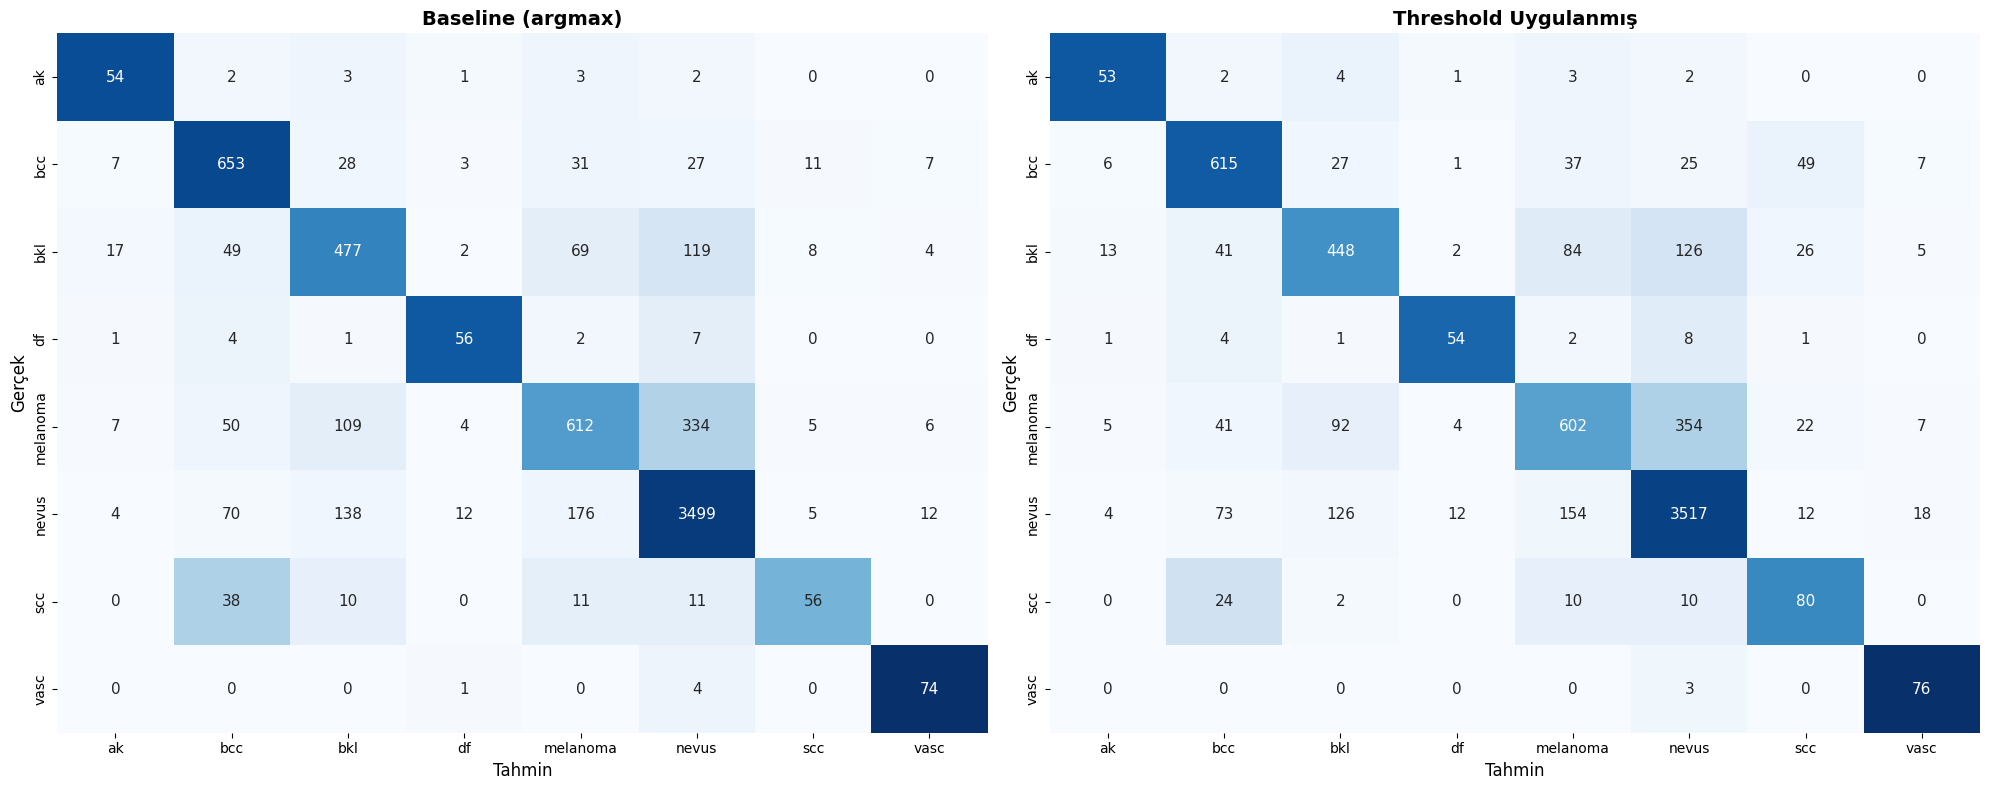

Confusion matrix kaydedildi ✅


In [18]:
# Confusion Matrix (threshold'lu)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, preds, title in zip(
    axes,
    [test_preds_base, test_preds_thr],
    ["Baseline (argmax)", "Threshold Uygulanmış"]
):
    cm = confusion_matrix(test_labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt="d",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, cbar=False,
                annot_kws={"size": 11})
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Tahmin", fontsize=12)
    ax.set_ylabel("Gerçek", fontsize=12)

plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix kaydedildi ✅")

## 11. TTA — Test Time Augmentation (Opsiyonel, +%1-2 accuracy)

In [19]:
# TTA: her görüntüyü 5 farklı şekilde dönüştür, ortalamasını al
tta_transforms = [
    A.Compose([A.Resize(224,224),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.HorizontalFlip(p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.VerticalFlip(p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(256,256), A.CenterCrop(224,224),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.Rotate(limit=15, p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
]

model.eval()
tta_probs_all = []
tta_labels_all = []

print("TTA başlıyor...")
for i in range(0, len(test_dataset), 1):
    row = test_dataset.df.iloc[i]
    img_path = row["image_path"]
    lbl = row["label_idx"]

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    probs_tta = []
    with torch.no_grad():
        for tfm in tta_transforms:
            t_img = tfm(image=img_rgb)["image"].unsqueeze(0).to(device)
            out = model(t_img)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            probs_tta.append(prob)

    mean_prob = np.mean(probs_tta, axis=0)
    tta_probs_all.append(mean_prob)
    tta_labels_all.append(lbl)

    if i % 500 == 0:
        print(f"  {i}/{len(test_dataset)}")

tta_probs_all  = np.array(tta_probs_all)
tta_labels_all = np.array(tta_labels_all)
tta_preds      = tta_probs_all.argmax(axis=1)

tta_acc = (tta_preds == tta_labels_all).mean()
tta_f1  = f1_score(tta_labels_all, tta_preds, average="macro", zero_division=0)
print(f"TTA Accuracy: {tta_acc:.4f}")
print(f"TTA Macro-F1: {tta_f1:.4f}")
print()
print(classification_report(tta_labels_all, tta_preds,
                             target_names=CLASS_NAMES, zero_division=0))

TTA başlıyor...
  0/6896
  500/6896
  1000/6896
  1500/6896
  2000/6896
  2500/6896
  3000/6896
  3500/6896
  4000/6896
  4500/6896
  5000/6896
  5500/6896
  6000/6896
  6500/6896
TTA Accuracy: 0.8010
TTA Macro-F1: 0.7254

              precision    recall  f1-score   support

          ak       0.54      0.88      0.67        65
         bcc       0.77      0.87      0.82       767
         bkl       0.64      0.67      0.65       745
          df       0.69      0.83      0.75        71
    melanoma       0.66      0.60      0.63      1127
       nevus       0.90      0.87      0.89      3916
         scc       0.65      0.54      0.59       126
        vasc       0.70      0.96      0.81        79

    accuracy                           0.80      6896
   macro avg       0.69      0.78      0.73      6896
weighted avg       0.80      0.80      0.80      6896



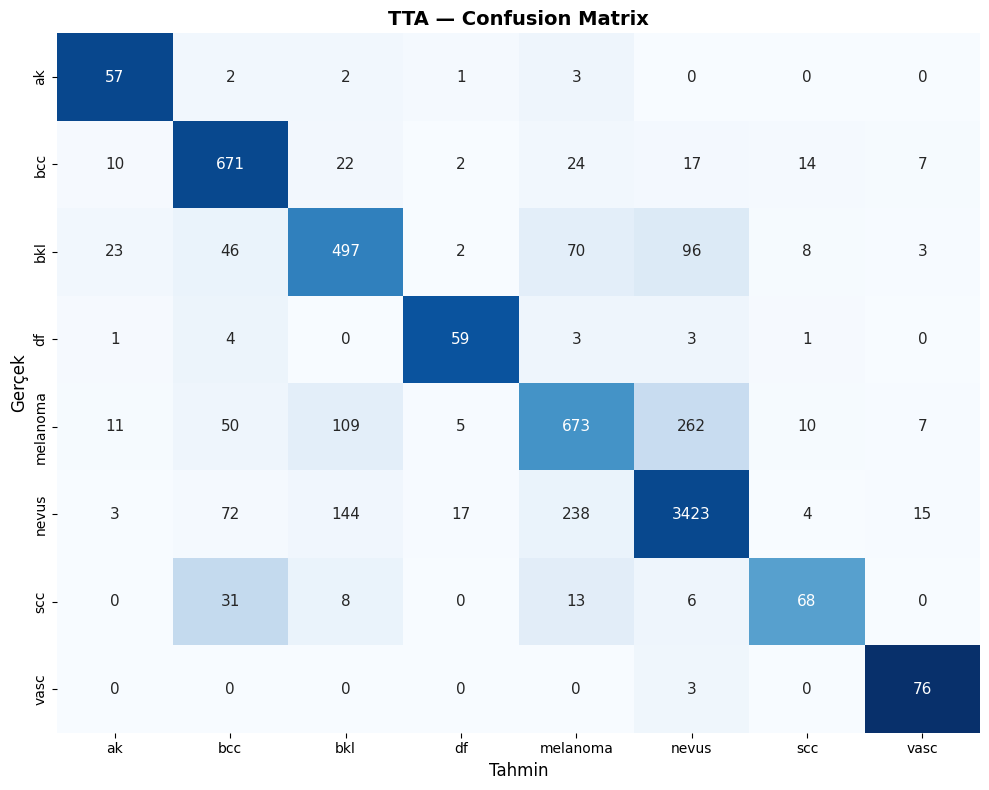

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(tta_labels_all, tta_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=cm, fmt="d",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap="Blues", ax=ax, cbar=False,
            annot_kws={"size": 11})
ax.set_title("TTA — Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Tahmin", fontsize=12)
ax.set_ylabel("Gerçek", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/confusion_matrix_tta.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Özet ve Sonraki Adımlar

In [20]:
print("=" * 60)
print("SONUÇ ÖZETİ")
print("=" * 60)
print(f"Model:            EfficientNetV2-S")
print(f"Train örnekleri:  {len(balanced_train_df)} (dengeli)")
print(f"Val örnekleri:    {len(val_df)}")
print(f"Test örnekleri:   {len(test_df)}")
print()
print(f"Test Accuracy  (baseline):   {base_acc:.4f}")
print(f"Test Macro-F1  (baseline):   {base_f1:.4f}")
print(f"Test Accuracy  (threshold):  {thr_acc:.4f}")
print(f"Test Macro-F1  (threshold):  {thr_f1:.4f}")
print(f"Test Accuracy  (TTA):        {tta_acc:.4f}")
print(f"Test Macro-F1  (TTA):        {tta_f1:.4f}")
print()
print("Model kayıt yolu:", SAVE_PATH)
print()
print("Sonraki adımlar:")
print("  1. Macro-F1 > 0.65 ise Grad-CAM ekle (XAI)")
print("  2. Macro-F1 < 0.60 ise ConvNeXt-S dene (timm'de mevcut)")
print("  3. Ensemble: bu model + v1 best_model.pth")

SONUÇ ÖZETİ
Model:            EfficientNetV2-S
Train örnekleri:  16000 (dengeli)
Val örnekleri:    5517
Test örnekleri:   6896

Test Accuracy  (baseline):   0.7948
Test Macro-F1  (baseline):   0.7131
Test Accuracy  (threshold):  0.7896
Test Macro-F1  (threshold):  0.7061
Test Accuracy  (TTA):        0.8010
Test Macro-F1  (TTA):        0.7254

Model kayıt yolu: /content/drive/MyDrive/SkinXAI/models_v3/skinxai_v3_best.pth

Sonraki adımlar:
  1. Macro-F1 > 0.65 ise Grad-CAM ekle (XAI)
  2. Macro-F1 < 0.60 ise ConvNeXt-S dene (timm'de mevcut)
  3. Ensemble: bu model + v1 best_model.pth
